# 3D Medical Image Segmentation Setup Demo

This notebook documents a reproducible setup for nnU-Net style medical image segmentation experiments, including data organization, inference, and metric checks.

## Configuration

This section defines the working directory, package setup, and folder structure used by the segmentation workflow.

In [ ]:
# Working directory for this notebook.
data_root = 'data/medical_segmentation_demo/runtime_data'


### Runtime Data Workspace

The notebook uses a local data workspace so the nnU-Net folder structure can be reproduced without exposing private dataset paths.


The working directory is created when it is not already present.

In [ ]:
if not os.path.isdir(data_root):
  os.makedirs(data_root)


### Utility Package

The helper package provides image IO and visualization utilities used later in the workflow.

Import the utilities package

### nnU-Net Setup

The nnU-Net codebase is installed in editable mode so the runtime can access the segmentation commands and project structure.

In [ ]:
# Set an environment variable for the path where we will clone the nnUNet repository
os.environ['NNUNET_REPO']=os.path.join(data_root, 'nnUNet')

# This system command clones the repository if it does not exist
!if [[ ! -d $NNUNET_REPO ]]; then git clone https://github.com/MIC-DKFZ/nnUNet.git $NNUNET_REPO; fi

# This command installs nnUNet on the runtime
!cd $NNUNET_REPO && pip install -e .

# This command installs an optional package used by nnUNet
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git


Setup log omitted.
 Installing build dependencies ... done
 Checking if build backend supports build_editable ... done
 Getting requirements to build editable ... done
 Preparing editable metadata (pyproject.toml) ... done
 Preparing metadata (setup.py) ... done
 Preparing metadata (setup.py) ... done
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.1 MB/s eta 0:00:00
 Preparing metadata (setup.py) ... done
 Installing build dependencies ... done
 Getting requirements to build wheel ... done
 Preparing metadata (pyproject.toml) ... done
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 MB 22.8 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.5 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 87.0 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 95.0 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.9 MB/s eta 0

The next block creates the raw-data, preprocessed-data, and results directories expected by nnU-Net, then sets the corresponding environment variables.

In [ ]:
for d in ['nnUNet_raw','nnUNet_preprocessed','nnUNet_results']:
  d_fullpath = os.path.join(data_root, d)
  os.makedirs(d_fullpath, exist_ok=True)
  os.environ[d] = d_fullpath
  print(f'Setting {d}={d_fullpath}')


Setup log omitted.
Setup log omitted.
Setup log omitted.


## nnU-Net Installation

## Organize Data for nnU-Net
### Rename Data Files


In [ ]:
import os
import shutil

# Define paths for the original and nnU-Net-formatted folders
original_folder = 'data/medical_segmentation_demo/original_name'
data_root = 'data/medical_segmentation_demo/runtime_data/'
renamed_folder = os.path.join(data_root, 'nnUNet_raw', 'Dataset001')

# Create the imagesTr and labelsTr subfolders inside the nnUNet_raw folder
imagesTr_folder = os.path.join(renamed_folder, 'imagesTr')
labelsTr_folder = os.path.join(renamed_folder, 'labelsTr')
os.makedirs(imagesTr_folder, exist_ok=True)
os.makedirs(labelsTr_folder, exist_ok=True)

# Copy and rename files into the nnU-Net convention
def copy_and_rename_files(original_folder, imagesTr_folder, labelsTr_folder):
    for filename in os.listdir(original_folder):
        if filename.endswith('.nii.gz'):
            parts = filename.split('_')

            if len(parts) == 5:
                subj = parts[0]
                modality = parts[3] + "_" + parts[4]
                if 't2_n4' in modality:
                    new_subj = subj.replace('subj', 'subj')
                    new_filename = f"{new_subj}_0000.nii.gz"
                    shutil.copy(os.path.join(original_folder, filename), os.path.join(imagesTr_folder, new_filename))

            elif len(parts) == 4:
                subj = parts[0]
                modality = parts[3]

                if 'ciss' in modality:
                    new_subj = subj.replace('subj', 'subj')
                    new_filename = f"{new_subj}_0001.nii.gz"
                    shutil.copy(os.path.join(original_folder, filename), os.path.join(imagesTr_folder, new_filename))

                elif 'final' in modality:
                    new_subj = subj.replace('subj', 'subj')
                    new_filename = f"{new_subj}.nii.gz"
                    shutil.copy(os.path.join(original_folder, filename), os.path.join(labelsTr_folder, new_filename))

            else:
                print(f"Skipping file: {filename} (format mismatch)")

# Execute the function
copy_and_rename_files(original_folder, imagesTr_folder, labelsTr_folder)

print("File copying and renaming completed!")


File copying and renaming completed!


In [ ]:
import os

# Define the path for the labelsTr folder
data_root = 'data/medical_segmentation_demo/runtime_data/nnUNet_raw/Dataset001'
labelsTr_folder = os.path.join(data_root, 'labelsTr')

# Count training label files in labelsTr
def count_num_training_files(labels_folder):
    return len([f for f in os.listdir(labels_folder) if f.endswith('.nii.gz')])

# Count training files
num_training = count_num_training_files(labelsTr_folder)

print(f"Number of training cases: {num_training}")


Number of training cases: 20


### Dataset Metadata JSON

In [ ]:
import json
import os

# Define the path for the nnUNet_raw folder
data_root = 'data/medical_segmentation_demo/runtime_data/'
nnUNet_raw_folder = os.path.join(data_root, 'nnUNet_raw')
json_file_path = os.path.join(nnUNet_raw_folder, 'Dataset001/dataset.json')

# Dataset metadata written to dataset.json
data = {
    "channel_names": {
        "0": "T2",
        "1": "CISS"
    },
    "labels": {
        "background": 0,
        "cortex_gray_matter": 1,
        "normal_white_matter": 2,
        "WMH": 3,
        "subcortical_gray_matter": 4,
        "other": 5
    },
    "numTraining": 20,
    "file_ending": ".nii.gz",
    "overwrite_image_reader_writer": "SimpleITKIO"
}

# Write JSON data to the specified file
def write_json(file_path, data):
    with open(file_path, 'w') as json_file:
        json.dump(data, json_file, indent=4)
    print(f"JSON file saved at: {file_path}")

# Generate the dataset.json file
write_json(json_file_path, data)


JSON file saved at: <local-data-path>


### Planning and Preprocessing

In [ ]:
!nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity

Setup log omitted.
Dataset001
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer
WARNING! Not all input images have the same origin!
Origins:
[(-74.0, -149.0, 102.0), (42.50691223144531, 56.26332092285156, -73.57006072998047)]
Image files:
['<local-data-path>', '<local-data-path>']
It is up to you to decide whether that's a problem. You should run nnUNetv2_plot_overlay_pngs to verify that segmentations and data overlap.
Origin images: (46.99486541748047, -111.09738159179688, -59.71223068237305). 
Origin seg: (15.7948637008667, -44.79737854003906, -36.61222839355469). 
Image files: ['<local-data-path>', '<local-data-path>']. 
Seg file: <local-data-path>

Origin images: (22.06595230102539, 41.22958755493164, -48.132713317871094). 
Origin seg: (20.56595230102539, 3.729586362838745, -52.032711029052734). 
Image files: ['<local-data-path>', '<local-data-path>']. 
Seg file: <local-data-path>


####################
verify_dataset_integrity Done. 
If you didn't 

## Training and Segmentation Metrics

This section runs nnU-Net training and summarizes segmentation accuracy from validation outputs.

In [ ]:
!pip install triton

In [ ]:
!nnUNetv2_train 1 3d_fullres 0 --npz -tr nnUNetTrainer_10epochs --c
!nnUNetv2_train 1 3d_fullres 1 --npz -tr nnUNetTrainer_10epochs --c
!nnUNetv2_train 1 3d_fullres 2 --npz -tr nnUNetTrainer_10epochs --c
!nnUNetv2_train 1 3d_fullres 3 --npz -tr nnUNetTrainer_10epochs --c
!nnUNetv2_train 1 3d_fullres 4 --npz -tr nnUNetTrainer_10epochs --c


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0
<local-data-path> FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
 self.grad_scaler = GradScaler() if self.device.type == 'cuda' else None

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2024-10-15 06:27:18.387120: do_dummy_2d_data_aug: False
2024-10-15 06:27:18.39

### Validation Accuracy Statistics


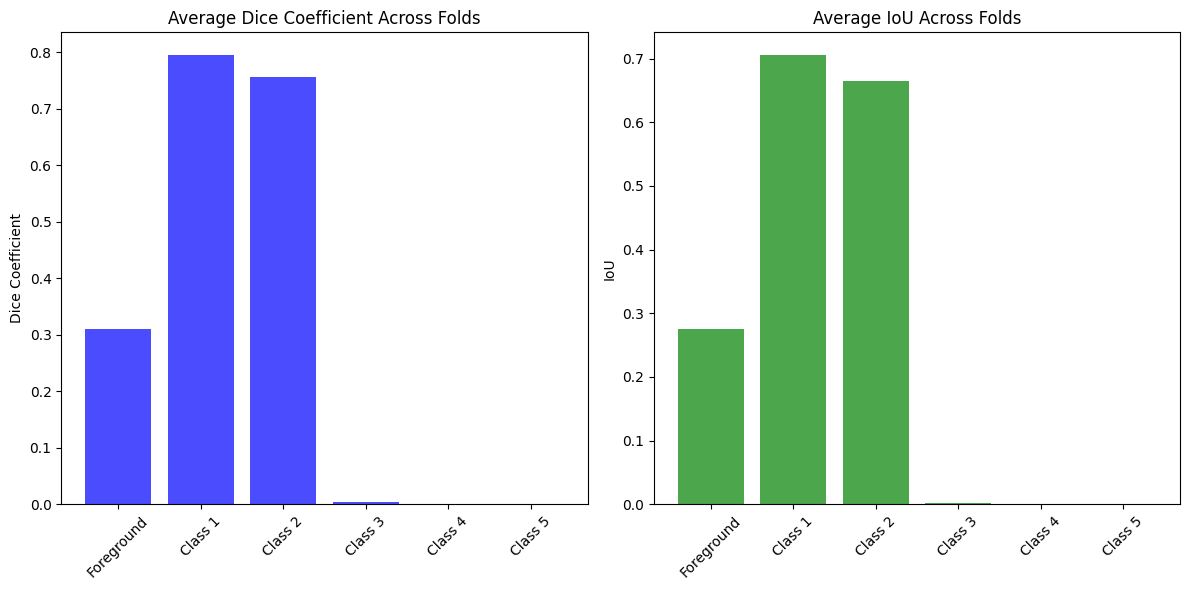

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Function to extract Dice and IoU from summary.json file
def extract_dice_iou(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
        foreground_dice = data["foreground_mean"]["Dice"]
        foreground_iou = data["foreground_mean"]["IoU"]

        mean_dice = []
        mean_iou = []

        # Extract Dice and IoU for each class (1, 2, 3, etc.)
        for class_id in data["mean"].keys():
            class_data = data["mean"][class_id]
            mean_dice.append(class_data["Dice"])
            mean_iou.append(class_data["IoU"])

    return foreground_dice, foreground_iou, mean_dice, mean_iou

# Function to calculate the average Dice and IoU across folds
def calculate_average_metrics(fold_paths):
    fold_foreground_dice = []
    fold_foreground_iou = []
    fold_mean_dice = []
    fold_mean_iou = []

    for file_path in fold_paths:
        foreground_dice, foreground_iou, mean_dice, mean_iou = extract_dice_iou(file_path)
        fold_foreground_dice.append(foreground_dice)
        fold_foreground_iou.append(foreground_iou)
        fold_mean_dice.append(mean_dice)
        fold_mean_iou.append(mean_iou)

    # Convert lists to numpy arrays for easier manipulation
    fold_foreground_dice = np.array(fold_foreground_dice)
    fold_foreground_iou = np.array(fold_foreground_iou)
    fold_mean_dice = np.array(fold_mean_dice)
    fold_mean_iou = np.array(fold_mean_iou)

    # Calculate the average Dice and IoU for foreground and mean across folds
    avg_foreground_dice = np.mean(fold_foreground_dice)
    avg_foreground_iou = np.mean(fold_foreground_iou)
    avg_mean_dice = np.mean(fold_mean_dice, axis=0)
    avg_mean_iou = np.mean(fold_mean_iou, axis=0)

    return avg_foreground_dice, avg_foreground_iou, avg_mean_dice, avg_mean_iou

# List of paths to the 5 folds' summary.json files
fold_paths = [
    'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/fold_0/validation/summary.json',
    'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/fold_1/validation/summary.json',
    'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/fold_2/validation/summary.json',
    'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/fold_3/validation/summary.json',
    'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/fold_4/validation/summary.json'
]

# Calculate the average metrics across folds
avg_foreground_dice, avg_foreground_iou, avg_mean_dice, avg_mean_iou = calculate_average_metrics(fold_paths)

# Create a list for the x-axis labels
x_labels = ['Foreground'] + [f'Class {i}' for i in range(1, len(avg_mean_dice) + 1)]

# Combine foreground and mean data for plotting
all_dice = [avg_foreground_dice] + list(avg_mean_dice)
all_iou = [avg_foreground_iou] + list(avg_mean_iou)

# Set up the bar chart for Dice and IoU
plt.figure(figsize=(12, 6))

# Plot Dice scores
plt.subplot(1, 2, 1)
plt.bar(x_labels, all_dice, color='b', alpha=0.7)
plt.title('Average Dice Coefficient Across Folds')
plt.ylabel('Dice Coefficient')
plt.xticks(rotation=45)

# Plot IoU scores
plt.subplot(1, 2, 2)
plt.bar(x_labels, all_iou, color='g', alpha=0.7)
plt.title('Average IoU Across Folds')
plt.ylabel('IoU')
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.show()


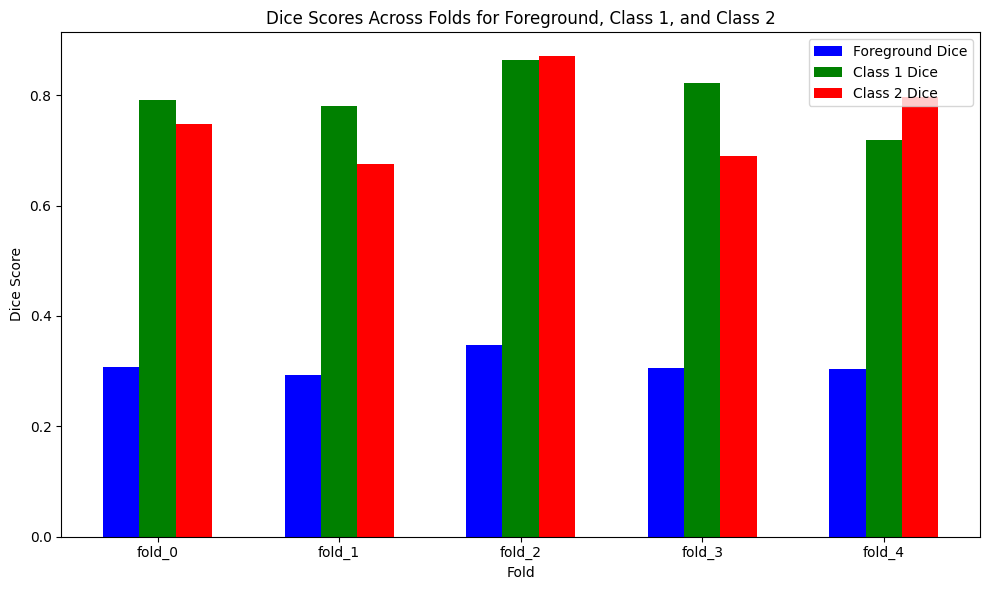

In [ ]:
import json
import os

# Root folder for validation outputs
results_folder = 'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/'

# List of folds
folds = ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']

# Store the results
results = {}

# Loop through each fold and extract the statistics
for fold in folds:
    summary_file = os.path.join(results_folder, f'nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/{fold}/validation/summary.json')

    # Load the JSON data from the file
    if os.path.exists(summary_file):
        with open(summary_file, 'r') as f:
            data = json.load(f)

        # Extract the Dice score for foreground, class 1, and class 2
        foreground_dice = data["foreground_mean"]["Dice"]
        class1_dice = data["mean"]["1"]["Dice"]
        class2_dice = data["mean"]["2"]["Dice"]

        # Add the result to the dictionary
        results[fold] = {
            'foreground_dice': foreground_dice,
            'class1_dice': class1_dice,
            'class2_dice': class2_dice
        }
    else:
        print(f"summary.json file not found for {fold}")

# Prepare data for plotting
fold_names = list(results.keys())
foreground_dices = [results[fold]['foreground_dice'] for fold in fold_names]
class1_dices = [results[fold]['class1_dice'] for fold in fold_names]
class2_dices = [results[fold]['class2_dice'] for fold in fold_names]

# Plotting
bar_width = 0.2
index = np.arange(len(fold_names))

plt.figure(figsize=(10, 6))

# Plot bars for foreground, class1, and class2
plt.bar(index, foreground_dices, bar_width, label='Foreground Dice', color='b')
plt.bar(index + bar_width, class1_dices, bar_width, label='Class 1 Dice', color='g')
plt.bar(index + 2 * bar_width, class2_dices, bar_width, label='Class 2 Dice', color='r')

# Labels and Titles
plt.xlabel('Fold')
plt.ylabel('Dice Score')
plt.title('Dice Scores Across Folds for Foreground, Class 1, and Class 2')
plt.xticks(index + bar_width, fold_names)

# Legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


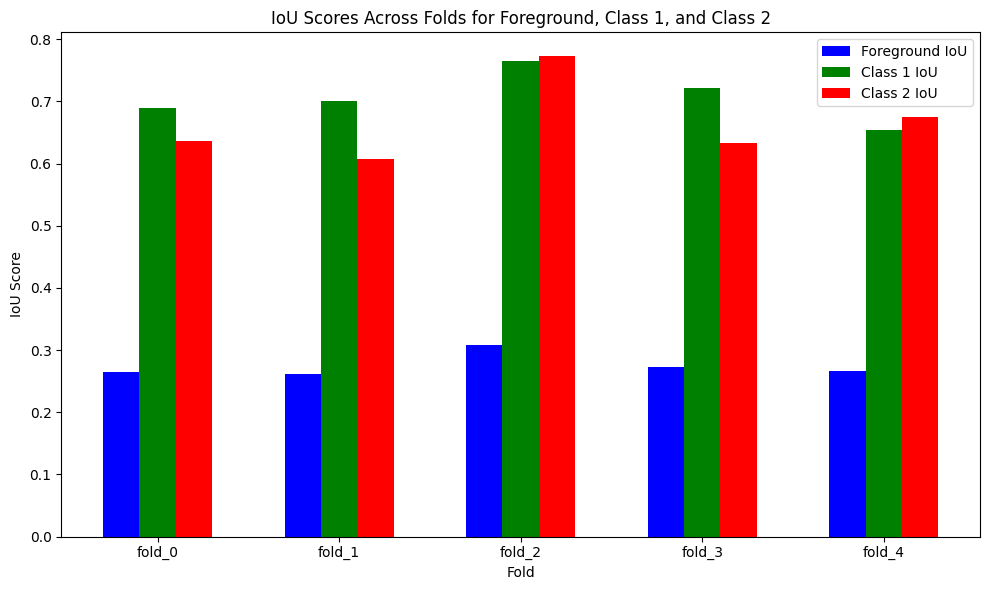

In [ ]:
# Loop through each fold and extract the statistics
for fold in folds:
    summary_file = os.path.join(results_folder, f'nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/{fold}/validation/summary.json')

    # Load the JSON data from the file
    if os.path.exists(summary_file):
        with open(summary_file, 'r') as f:
            data = json.load(f)

        # Extract the IoU score for foreground, class 1, and class 2
        foreground_iou = data["foreground_mean"]["IoU"]
        class1_iou = data["mean"]["1"]["IoU"]
        class2_iou = data["mean"]["2"]["IoU"]

        # Add the result to the dictionary
        results[fold] = {
            'foreground_iou': foreground_iou,
            'class1_iou': class1_iou,
            'class2_iou': class2_iou
        }
    else:
        print(f"summary.json file not found for {fold}")

# Prepare data for plotting
fold_names = list(results.keys())
foreground_ious = [results[fold]['foreground_iou'] for fold in fold_names]
class1_ious = [results[fold]['class1_iou'] for fold in fold_names]
class2_ious = [results[fold]['class2_iou'] for fold in fold_names]

# Plotting
bar_width = 0.2
index = np.arange(len(fold_names))

plt.figure(figsize=(10, 6))

# Plot bars for foreground, class1, and class2 IoU
plt.bar(index, foreground_ious, bar_width, label='Foreground IoU', color='b')
plt.bar(index + bar_width, class1_ious, bar_width, label='Class 1 IoU', color='g')
plt.bar(index + 2 * bar_width, class2_ious, bar_width, label='Class 2 IoU', color='r')

# Labels and Titles
plt.xlabel('Fold')
plt.ylabel('IoU Score')
plt.title('IoU Scores Across Folds for Foreground, Class 1, and Class 2')
plt.xticks(index + bar_width, fold_names)

# Legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import json
import os
import pandas as pd

# Root folder for validation outputs
results_folder = 'data/medical_segmentation_demo/runtime_data/nnUNet_results/Dataset001/'

# List of folds
folds = ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']

# Store the results for TN, TP, FN, FP
results = {
    'foreground': {'TN': [], 'TP': [], 'FN': [], 'FP': []},
    'class1': {'TN': [], 'TP': [], 'FN': [], 'FP': []},
    'class2': {'TN': [], 'TP': [], 'FN': [], 'FP': []}
}

# Function to extract TN, TP, FN, FP from the summary.json files
def extract_metrics(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

        # Extract metrics for foreground, class1, and class2
        foreground_metrics = {
            'TN': data["foreground_mean"]["TN"],
            'TP': data["foreground_mean"]["TP"],
            'FN': data["foreground_mean"]["FN"],
            'FP': data["foreground_mean"]["FP"]
        }

        class1_metrics = {
            'TN': data["mean"]["1"]["TN"],
            'TP': data["mean"]["1"]["TP"],
            'FN': data["mean"]["1"]["FN"],
            'FP': data["mean"]["1"]["FP"]
        }

        class2_metrics = {
            'TN': data["mean"]["2"]["TN"],
            'TP': data["mean"]["2"]["TP"],
            'FN': data["mean"]["2"]["FN"],
            'FP': data["mean"]["2"]["FP"]
        }

        return foreground_metrics, class1_metrics, class2_metrics

# Loop through each fold and extract the statistics
for fold in folds:
    summary_file = os.path.join(results_folder, f'nnUNetTrainer_10epochs__nnUNetPlans__3d_fullres/{fold}/validation/summary.json')

    # Load the JSON data from the file
    if os.path.exists(summary_file):
        foreground_metrics, class1_metrics, class2_metrics = extract_metrics(summary_file)

        # Store the results for each fold
        for key in results['foreground'].keys():
            results['foreground'][key].append(foreground_metrics[key])
            results['class1'][key].append(class1_metrics[key])
            results['class2'][key].append(class2_metrics[key])

    else:
        print(f"summary.json file not found for {fold}")

# Calculate the average for each metric across all folds
average_results = {
    'foreground': {metric: sum(values)/len(values) for metric, values in results['foreground'].items()},
    'class1': {metric: sum(values)/len(values) for metric, values in results['class1'].items()},
    'class2': {metric: sum(values)/len(values) for metric, values in results['class2'].items()}
}

# Create a DataFrame for better visualization
df = pd.DataFrame(average_results).T

# Rename columns to be more descriptive
df.columns = ['Mean TN', 'Mean TP', 'Mean FN', 'Mean FP']

df



 Mean TN Mean TP Mean FN Mean FP
foreground 216777.23 29470.37 7871.76 8024.64
class1 135707.15 89082.60 13977.70 23376.55
class2 168998.25 58260.60 19166.95 15718.20

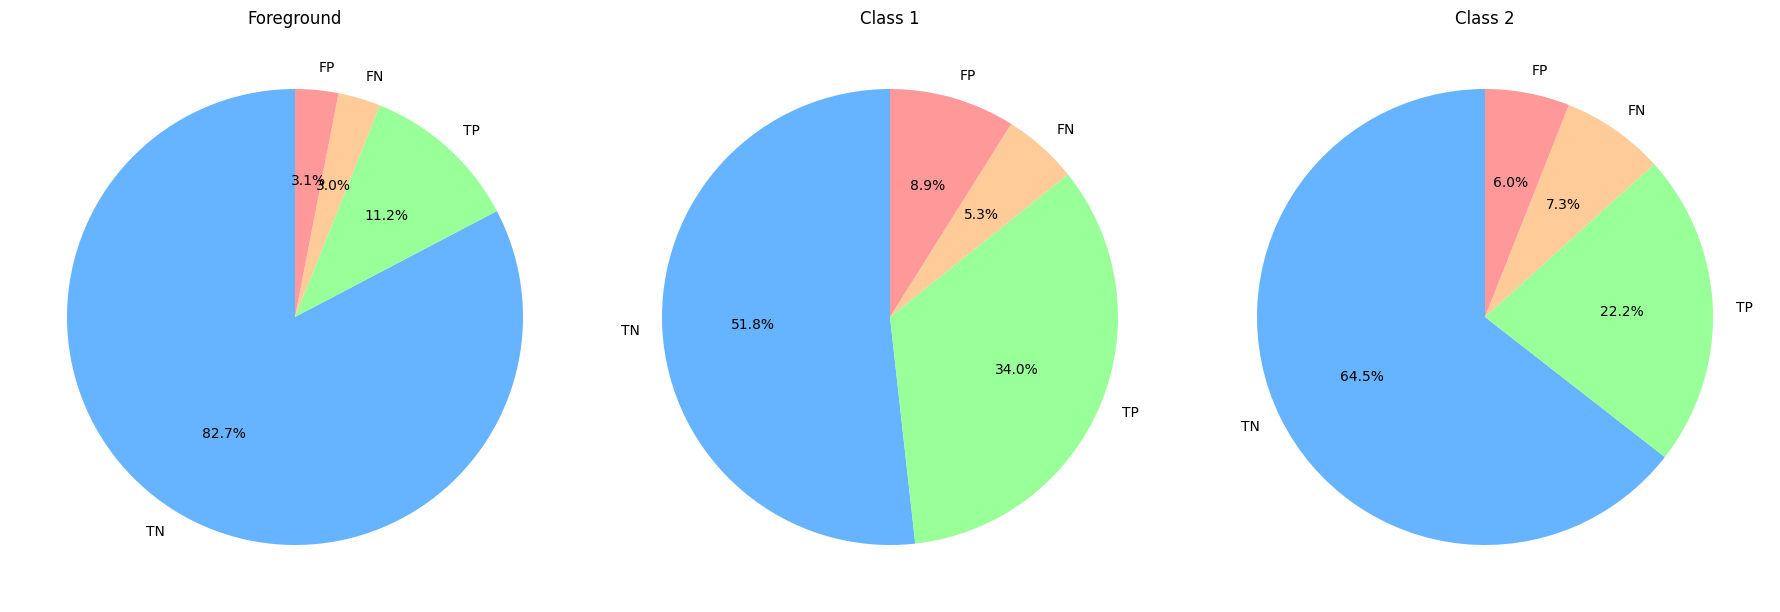

In [ ]:
# Plot 3 pie charts for TN, TP, FN, FP for foreground, class1, and class2
labels = ['TN', 'TP', 'FN', 'FP']

# Extract values for each class
foreground_values = df.loc['foreground'].values
class1_values = df.loc['class1'].values
class2_values = df.loc['class2'].values

# Create subplots for the 3 pie charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for foreground
axes[0].pie(foreground_values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])
axes[0].set_title('Foreground')

# Plot for class1
axes[1].pie(class1_values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])
axes[1].set_title('Class 1')

# Plot for class2
axes[2].pie(class2_values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])
axes[2].set_title('Class 2')

# Display the plots
plt.tight_layout()
plt.show()

### Segmentation Comparison


## Apply nnU-Net to Held-Out Whole-Hemisphere Images
### Expected Behaviour on Larger Field-of-View Images


I think nnU-Net may face challenges when handling whole-hemisphere images. During training, the model only saw small patches, and problematic areas, like poorly registered T2/CISS, were excluded. As a result, the model may struggle with such areas in the full images, leading to less accurate segmentations. In regions with no tissue, the model will likely label them as background, but there may still be some missegmentations due to noise. Overall, the performance might not be as consistent as with smaller patches.

### Prediction on Testing Images
#### Rename Testing Files


In [ ]:
import os
import shutil

# Define paths
data_root = 'data/medical_segmentation_demo/'
origin_folder = os.path.join(data_root, 'origin_name_testing')
base_destination_folder = os.path.join(data_root, 'testing_data_input')
base_output_folder = os.path.join(data_root, 'testing_data_output')  # Define base output path for predictions

# Create base destination and output folders (if they don't exist)
os.makedirs(base_destination_folder, exist_ok=True)
os.makedirs(base_output_folder, exist_ok=True)

# Traverse files in origin_name_testing, rename, copy, and create individual input/output folders for each case
def rename_and_copy_files(origin_folder, base_destination_folder, base_output_folder):
    # Initialize a set to track subject numbers (XXX)
    subjects = set()

    for filename in os.listdir(origin_folder):
        if filename.endswith('.nii.gz'):
            parts = filename.split('_')

            # Extract subject number (e.g., 'XXX' from 'subj_XXX_t2.nii.gz')
            subj = parts[1]  # Extract 'XXX'
            subjects.add(subj)  # Add subject number to the set

            # Determine file type and rename
            if 't2' in filename:
                new_filename = f"subj{subj}_0000.nii.gz"
            elif 'ciss' in filename:
                new_filename = f"subj{subj}_0001.nii.gz"
            else:
                print(f"Skipping file {filename} (not t2 or ciss)")
                continue

            # Create individual destination and output folders for each subject
            destination_folder = os.path.join(base_destination_folder, f'subj{subj}')
            output_folder = os.path.join(base_output_folder, f'subj{subj}')
            os.makedirs(destination_folder, exist_ok=True)
            os.makedirs(output_folder, exist_ok=True)

            # Copy file to the individual destination folder
            shutil.copy(os.path.join(origin_folder, filename), os.path.join(destination_folder, new_filename))
            print(f"Renamed and copied: {filename} -> {new_filename} to {destination_folder}")

    # Return the list of subject folders created
    return subjects

# Execute renaming and copying
subjects = rename_and_copy_files(origin_folder, base_destination_folder, base_output_folder)

print("Files renamed, copied, and organized by subject!")


Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Setup log omitted.
Files renamed, copied, and organized by subject!


### Prediction on Held-Out Cases

In [ ]:
import os

def run_prediction(subject_id):
    data_root = 'data/medical_segmentation_demo/'

    # Define the input and output folders based on the subject ID
    input_folder = os.path.join(data_root, 'testing_data_input', f'subj{subject_id}')
    output_folder = os.path.join(data_root, 'testing_data_output', f'subj{subject_id}')
    dataset_id = '1'
    configuration = '3d_fullres'

    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Run the prediction command using !
    !nnUNetv2_predict -i {input_folder} -o {output_folder} -d {dataset_id} -c {configuration} -tr nnUNetTrainer_10epochs

    print(f"Prediction for subj{subject_id} executed!")


In [ ]:
# Example: Run prediction for subj024
run_prediction('024')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('025')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('026')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('027')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('028')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('029')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('030')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('032')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

In [ ]:
run_prediction('033')


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

<local-data-path> FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

### Visual Inspection in ITK-SNAP

## Post-Processing Strategy

The segmentation outputs are refined with a lightweight connected-component and thresholding workflow before final inspection.

### Post-Process nnU-Net Segmentations


In [ ]:
import os
import SimpleITK as sitk

def run_otsu_postprocess(subject_id):
    data_root = 'data/medical_segmentation_demo/'

    # Define the input and output folders based on the subject ID
    input_folder = os.path.join(data_root, 'testing_data_input', f'subj{subject_id}')
    output_folder = os.path.join(data_root, 'testing_data_output', f'subj{subject_id}')

    # Paths to T2 and CISS images in the input folder
    t2_image_path = os.path.join(input_folder, f'subj{subject_id}_0000.nii.gz')  # T2 image
    ciss_image_path = os.path.join(input_folder, f'subj{subject_id}_0001.nii.gz')  # CISS image

    # Path to the segmentation result in the output folder
    segmentation_result_path = os.path.join(output_folder, f'subj{subject_id}.nii.gz')

    # Read images using SimpleITK
    t2_image = sitk.ReadImage(t2_image_path, sitk.sitkFloat32)
    ciss_image = sitk.ReadImage(ciss_image_path, sitk.sitkFloat32)
    segmentation_result = sitk.ReadImage(segmentation_result_path, sitk.sitkFloat32)

    # Apply Otsu thresholding on the CISS image to generate a brain mask
    otsu_filter = sitk.OtsuThresholdImageFilter()
    otsu_filter.SetInsideValue(0)
    otsu_filter.SetOutsideValue(1)
    brain_mask = otsu_filter.Execute(ciss_image)
    brain_mask = sitk.Cast(brain_mask, sitk.sitkFloat32)

    # Apply the brain mask to the segmentation result (multiply them)
    masked_segmentation = sitk.Multiply(segmentation_result, brain_mask)

    # Define the post-processed results folder path
    postprocessed_results_folder = os.path.join(data_root, 'post_processed_results')

    # Ensure the folder exists
    os.makedirs(postprocessed_results_folder, exist_ok=True)

    # Define the output path for the post-processed segmentation result
    postprocessed_output_path = os.path.join(postprocessed_results_folder, f'subj{subject_id}_masked.nii.gz')

    # Save the post-processed segmentation
    sitk.WriteImage(masked_segmentation, postprocessed_output_path)

    print(f"Post-processed segmentation saved for subject {subject_id} at: {postprocessed_output_path}")


In [ ]:
# List of subject IDs you want to process
subject_ids = ['024', '025', '026', '027', '028', '029', '030', '032', '033']

# Loop through each subject ID and apply the post-processing
for subject_id in subject_ids:
    run_otsu_postprocess(subject_id)


Post-processed segmentation saved for subject 024 at: <local-data-path>
Post-processed segmentation saved for subject 025 at: <local-data-path>
Post-processed segmentation saved for subject 026 at: <local-data-path>
Post-processed segmentation saved for subject 027 at: <local-data-path>
Post-processed segmentation saved for subject 028 at: <local-data-path>
Post-processed segmentation saved for subject 029 at: <local-data-path>
Post-processed segmentation saved for subject 030 at: <local-data-path>
Post-processed segmentation saved for subject 032 at: <local-data-path>
Post-processed segmentation saved for subject 033 at: <local-data-path>


### E.3 Examples of the post-processed images

## Quantitative Evaluation


In [ ]:
import os
import matplotlib.pyplot as plt
from medical_image_utils.landmarks import hemi_landmark_thickness
from scipy.stats import pearsonr

# Base paths for segmentation outputs and landmark measurements
data_root = 'data/medical_segmentation_demo/'
landmarks_folder = os.path.join(data_root, 'landmarks')
postprocessed_results_folder = os.path.join(data_root, 'post_processed_results')

# Define subject IDs
subject_ids = ['024', '025', '026', '027', '028', '029', '030', '032', '033']

# Store cortical thickness results
cortical_thickness = []

# Calculate thickness for each subject
for subject_id in subject_ids:
    segpath = os.path.join(postprocessed_results_folder, f'subj{subject_id}_masked.nii.gz')
    landmark_path = os.path.join(landmarks_folder, f'subj_{subject_id}_dots.nii.gz')

    # Compute cortical thickness
    result = hemi_landmark_thickness(segpath, landmark_path)
    cortical_thickness.append(result)
    print(f"Computed thickness for subject {subject_id}")

# Extract nnU-Net generated thickness values
motor_cortex_nn = [thickness['MotorCortex'] for thickness in cortical_thickness]
medial_frontal_nn = [thickness['MedialFrontalCortex'] for thickness in cortical_thickness]
anterior_temporal_nn = [thickness['AnteriorTemporalPole'] for thickness in cortical_thickness]

# Read reference thickness values from the CSV file
reference_csv_path = os.path.join(data_root, 'landmarks', 'reference_thickness.csv')
reference_thickness = {}

import csv
with open(reference_csv_path, mode='r') as file:
    csv_reader = csv.DictReader(file)
    for row in csv_reader:
        subject_id = row['Id'].split('_')[1]  # Extract 'XXX' part from 'subj_XXX'
        reference_thickness[subject_id] = {
            'MotorCortex': float(row['MotorCortex']),
            'MedialFrontalCortex': float(row['MedialFrontalCortex']),
            'AnteriorTemporalPole': float(row['AnteriorTemporalPole'])
        }

# Extract reference thickness values
motor_cortex_ref = [reference_thickness[sub_id]['MotorCortex'] for sub_id in subject_ids]
medial_frontal_ref = [reference_thickness[sub_id]['MedialFrontalCortex'] for sub_id in subject_ids]
anterior_temporal_ref = [reference_thickness[sub_id]['AnteriorTemporalPole'] for sub_id in subject_ids]

# Compute Pearson correlation coefficients
motor_cortex_corr, _ = pearsonr(motor_cortex_nn, motor_cortex_ref)
medial_frontal_corr, _ = pearsonr(medial_frontal_nn, medial_frontal_ref)
anterior_temporal_corr, _ = pearsonr(anterior_temporal_nn, anterior_temporal_ref)

# Print correlation results
print(f"Motor Cortex Pearson Correlation: {motor_cortex_corr}")
print(f"Medial Frontal Cortex Pearson Correlation: {medial_frontal_corr}")
print(f"Anterior Temporal Pole Pearson Correlation: {anterior_temporal_corr}")


Computed thickness for subject 024
Computed thickness for subject 025
Computed thickness for subject 026
Computed thickness for subject 027
Computed thickness for subject 028
Computed thickness for subject 029
Computed thickness for subject 030
Computed thickness for subject 032
Computed thickness for subject 033
Motor Cortex Pearson Correlation: 0.00955850906868449
Medial Frontal Cortex Pearson Correlation: 0.63118381975443
Anterior Temporal Pole Pearson Correlation: 0.2355689502743654


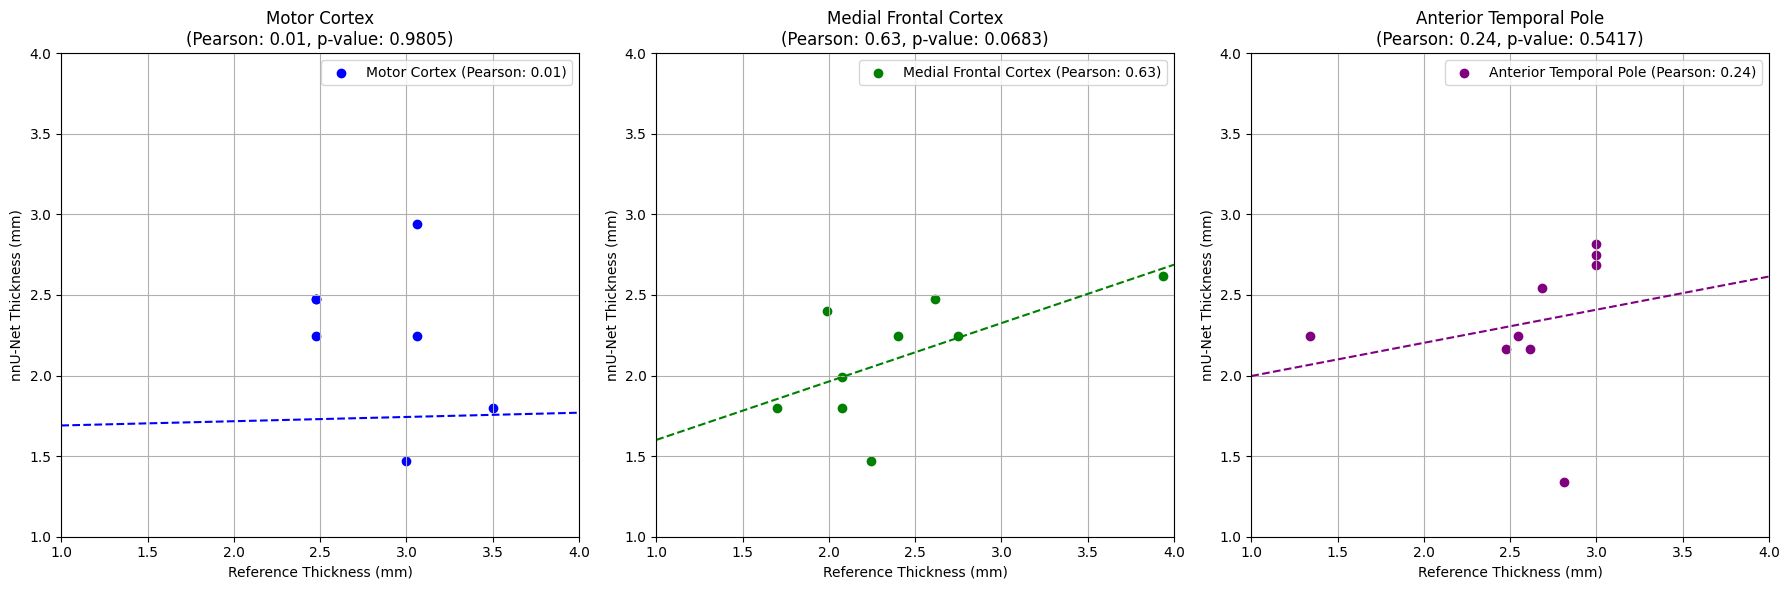

Pearson correlation coefficients, p-values, and slopes:
Motor Cortex: Correlation = 0.0096, p-value = 0.9805
Medial Frontal Cortex: Correlation = 0.6312, p-value = 0.0683
Anterior Temporal Pole: Correlation = 0.2356, p-value = 0.5417


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Define x-axis range
x_values = np.linspace(1, 4, 100)

# Create subplots: 1 row, 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Motor Cortex
m_motor, b_motor = np.polyfit(motor_cortex_ref, motor_cortex_nn, 1)
corr_motor, p_motor = pearsonr(motor_cortex_ref, motor_cortex_nn)  # Pearson correlation and p-value
axs[0].scatter(motor_cortex_ref, motor_cortex_nn, color='blue', label=f'Motor Cortex (Pearson: {corr_motor:.2f})')
axs[0].plot(x_values, m_motor * x_values + b_motor, 'blue', linestyle='--')
axs[0].set_xlabel('Reference Thickness (mm)')
axs[0].set_ylabel('nnU-Net Thickness (mm)')
axs[0].set_title(f'Motor Cortex\n(Pearson: {corr_motor:.2f}, p-value: {p_motor:.4f})')
axs[0].legend()
axs[0].set_xlim(1, 4)
axs[0].set_ylim(1, 4)
axs[0].grid(True)

# Medial Frontal Cortex
m_medial, b_medial = np.polyfit(medial_frontal_ref, medial_frontal_nn, 1)
corr_medial, p_medial = pearsonr(medial_frontal_ref, medial_frontal_nn)  # Pearson correlation and p-value
axs[1].scatter(medial_frontal_ref, medial_frontal_nn, color='green', label=f'Medial Frontal Cortex (Pearson: {corr_medial:.2f})')
axs[1].plot(x_values, m_medial * x_values + b_medial, 'green', linestyle='--')
axs[1].set_xlabel('Reference Thickness (mm)')
axs[1].set_ylabel('nnU-Net Thickness (mm)')
axs[1].set_title(f'Medial Frontal Cortex\n(Pearson: {corr_medial:.2f}, p-value: {p_medial:.4f})')
axs[1].legend()
axs[1].set_xlim(1, 4)
axs[1].set_ylim(1, 4)
axs[1].grid(True)

# Anterior Temporal Pole
m_anterior, b_anterior = np.polyfit(anterior_temporal_ref, anterior_temporal_nn, 1)
corr_anterior, p_anterior = pearsonr(anterior_temporal_ref, anterior_temporal_nn)  # Pearson correlation and p-value
axs[2].scatter(anterior_temporal_ref, anterior_temporal_nn, color='purple', label=f'Anterior Temporal Pole (Pearson: {corr_anterior:.2f})')
axs[2].plot(x_values, m_anterior * x_values + b_anterior, 'purple', linestyle='--')
axs[2].set_xlabel('Reference Thickness (mm)')
axs[2].set_ylabel('nnU-Net Thickness (mm)')
axs[2].set_title(f'Anterior Temporal Pole\n(Pearson: {corr_anterior:.2f}, p-value: {p_anterior:.4f})')
axs[2].legend()
axs[2].set_xlim(1, 4)
axs[2].set_ylim(1, 4)
axs[2].grid(True)

# Adjust layout for better spacing between plots
plt.tight_layout()
plt.show()

# Print correlation coefficients, p-values, and slopes for each region
print("Pearson correlation coefficients, p-values, and slopes:")
print(f"Motor Cortex: Correlation = {corr_motor:.4f}, p-value = {p_motor:.4f}")
print(f"Medial Frontal Cortex: Correlation = {corr_medial:.4f}, p-value = {p_medial:.4f}")
print(f"Anterior Temporal Pole: Correlation = {corr_anterior:.4f}, p-value = {p_anterior:.4f}")
